# Definition

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from scipy.special import gamma

import numba

from lattice import Graphene


from matplotlib.patches import Polygon


import matplotlib.pyplot as plt

import numpy as np
from scipy.special import gamma
from scipy.sparse.linalg import expm_multiply
from scipy.sparse import bmat, diags, block_diag

import numba
from lattice import Graphene

from simulation import System, Eletric_field, Leg
from simulation import add_atom_to_hamiltonian, time_evolution

from utils import draw_basis_vectors, draw_electric_field, annotate_electric_field_text, separate_each_lattice, plot_graphene

In [30]:

def compute_positions_along_direction_a1(lattice):
  NMAX = lattice.nmax
  a1 = lattice.a1
  a2 = lattice.a2
  d1 = lattice.d1

  m = np.arange(-(NMAX//2), NMAX//2)
  
  na_line = []
  nb_line = []

  n = 0.
  for mm in m:
    ra = mm * a1

    na_line.append(ra)

    rb = mm * a1 + d1
    nb_line.append(rb)

  return np.array(na_line).T, np.array(nb_line).T


def compute_positions_along_line(lattice):
  """
    Computes real lattice positions for sites that lie n a line at y = 0. The
    positions that fullfil such a thing are giving by

    $R_a = n a_1 + m a_2$, such that $n = -2m$ and
    $R_b = n a_1 + m a_2 + \delta$, such that $n =1 -2m$
  """
  NMAX = lattice.nmax
  a1 = lattice.a1
  a2 = lattice.a2
  d1 = lattice.d1

  m = np.arange(-(NMAX//2), NMAX//2)

  na_line = []
  nb_line = []

  for mm in m:
    n = - 2 * mm
    if n in m:
      ra = n * a1 + mm * a2
      na_line.append(ra)
  
    n = 1 - 2 * mm
    if n in m:
      rb = n * a1 + mm * a2 + d1
      nb_line.append(rb)

  return np.array(na_line).T, np.array(nb_line).T


def join_arrays_interchange(x1, x2):
    return np.stack([x1, x2], axis=0).T.flatten()


def compute_position_legs(sys):
    a1 = sys.lattice.a1
    a2 = sys.lattice.a2
    R = []
    for leg in sys.legs:
        pos = leg.pos
        R.append(pos[0] * a1 + pos[1] * a2)
    return R


def compute_phase(r1, r2, tau):
    phi = 1 - 2 * tau / 3 * ((r2[0] - r1[0]) - (r2[1] - r1[1]))
    phi *= np.pi

    return phi

<>:25: SyntaxWarning: invalid escape sequence '\d'
<>:25: SyntaxWarning: invalid escape sequence '\d'
/var/folders/q3/1z3g104x46n7562_5r_mvpl80000gn/T/ipykernel_66742/2917516490.py:25: SyntaxWarning: invalid escape sequence '\d'
  """


In [28]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Avenir', 'DejaVu Sans', 'Lucida Grande', 'Verdana']
plt.rcParams['font.size'] = 25
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 30  # x-axis tick labels
plt.rcParams['ytick.labelsize'] = 30 

# Normal Atom

In [86]:
NMAX = 551
delta = 0.5
lambda_0 = 4
x0 = 0.
# OMEGA_0 = 0.014
OMEGA_0 = 0.
G = 0.3
atom_pos = (0,0)
NUM_POINTS = 25
TF = 230

t = np.linspace(0, TF, NUM_POINTS)
lattice = Graphene(nmax=NMAX, x0=x0, delta_0=delta, lambda_0=lambda_0, pbc="y", domain_wall_angle=0)

na, nb = lattice.n_real_pos

H = lattice.hamiltonian
new_dimension = lattice.num_sites() + 1
H.resize((new_dimension, new_dimension))
H = H.astype(np.cdouble)

H[-1, -1] = OMEGA_0
idx = lattice.coord_map["A"][atom_pos]

H[-1, idx] = G
H[idx, -1] = G

psi = np.zeros(new_dimension, dtype=np.cdouble)
psi[-1] = 1.

psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)

psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:lattice.la]
psi_b = psi_latt[:,lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2

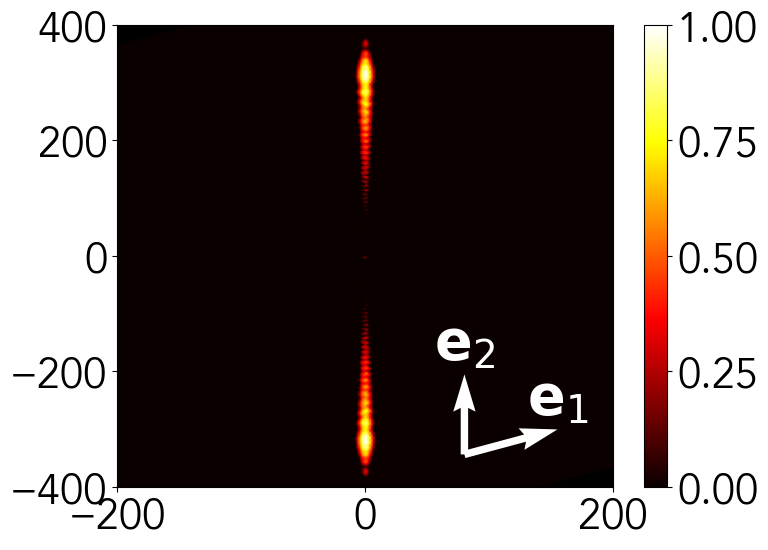

In [87]:
FIG_SIZE = (8, 6)
FILL = True
LOG_SCALE = True
VMAX = None
VMIN = -4.5


fig, ax = plt.subplots(figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], ax, s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE, rescale_to_0_1=True)

fig.colorbar(im, ax=ax, ticks=[0., 0.25, 0.5, 0.75, 1.])

if FILL:
    ax.set_facecolor("black")


ax.set_ylim(-400,400)
ax.set_xlim(-200, 200)

draw_basis_vectors(ax, [lattice.a1, lattice.a2], labels=(r"${\bf e}_1$", r"${\bf e}_2$"), pos=(0.7, 0.07), fontsize=40, scale=(50, 80), width=0.015)
plt.show()

fig.tight_layout()
# fig.savefig(PATH + "emission_normal_atom.pdf", bbox_inches="tight")


In [88]:
# Decay rate semi-numerical
vf = 3/2

a1, a2 = lattice.a1, lattice.a2
na, nb = compute_positions_along_direction_a1(lattice)
beta = delta * lambda_0 / vf

psi_x = (1/np.cosh(na[0]/lambda_0)) ** (beta)
x = join_arrays_interchange(nb[0], na[0])

A = 1/np.sqrt(np.sum((1/np.cosh(na[0]/lambda_0)) ** (2*beta)))



r0 = atom_pos[0] * a1 + atom_pos[1] * a2
x0 = r0[0]

psi_x0 = ((1/np.cosh(x0/lambda_0)) ** beta) * A

decay_semi_num = (G ** 2) * np.sqrt(3) * np.abs(psi_x0) **2 / vf

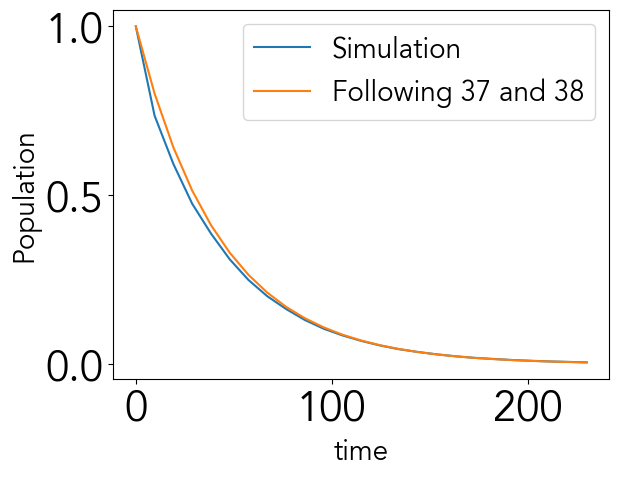

In [89]:
plt.plot(t, pe, label="Simulation")
# plt.plot(t, np.exp(-t * decay_rate), label='decay like eq 42')
plt.plot(t, np.exp(-t * decay_semi_num), label='Following 37 and 38')

# plt.plot(t, np.exp(-t * decay_rate_francesco), label='Decay rate 2')
plt.xlabel("time")
plt.ylabel("Population")

plt.legend(fontsize=20)

In [121]:
NMAX = 551
delta = 0.5
lambda_0 = 4
x0 = 0.
# OMEGA_0 = 0.014
OMEGA_0 = 0.
G = 0.3
atom_pos = (1,2)
NUM_POINTS = 25
TF = 230

t = np.linspace(0, TF, NUM_POINTS)
lattice = Graphene(nmax=NMAX, x0=x0, delta_0=delta, lambda_0=lambda_0, pbc="y", domain_wall_angle=0)

na, nb = lattice.n_real_pos

H = lattice.hamiltonian
new_dimension = lattice.num_sites() + 1
H.resize((new_dimension, new_dimension))
H = H.astype(np.cdouble)

H[-1, -1] = OMEGA_0
idx = lattice.coord_map["A"][atom_pos]

H[-1, idx] = G
H[idx, -1] = G

psi = np.zeros(new_dimension, dtype=np.cdouble)
psi[-1] = 1.

psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)

psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:lattice.la]
psi_b = psi_latt[:,lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2

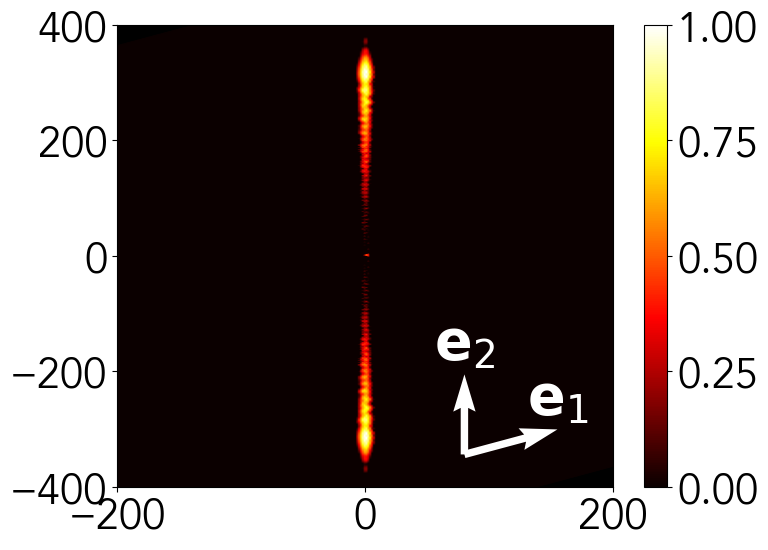

In [123]:
FIG_SIZE = (8, 6)
FILL = True
LOG_SCALE = True
VMAX = None
VMIN = -4.5


fig, ax = plt.subplots(figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], ax, s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE, rescale_to_0_1=True)

fig.colorbar(im, ax=ax, ticks=[0., 0.25, 0.5, 0.75, 1.])

if FILL:
    ax.set_facecolor("black")


ax.set_ylim(-400,400)
ax.set_xlim(-200, 200)

draw_basis_vectors(ax, [lattice.a1, lattice.a2], labels=(r"${\bf e}_1$", r"${\bf e}_2$"), pos=(0.7, 0.07), fontsize=40, scale=(50, 80), width=0.015)
plt.show()

fig.tight_layout()
# fig.savefig(PATH + "emission_normal_atom.pdf", bbox_inches="tight")


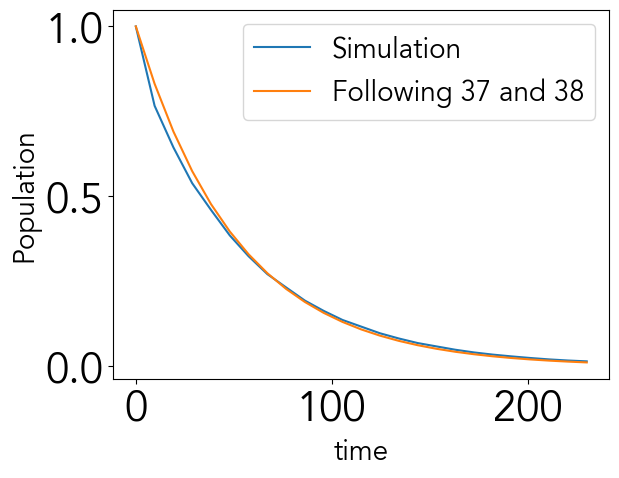

In [ ]:
# Decay rate semi-numerical
vf = 3/2

a1, a2 = lattice.a1, lattice.a2
na, nb = compute_positions_along_direction_a1(lattice)
beta = delta * lambda_0 / vf

psi_x = (1/np.cosh(na[0]/lambda_0)) ** (beta)
x = join_arrays_interchange(nb[0], na[0])

A = 1/np.sqrt(np.sum((1/np.cosh(na[0]/lambda_0)) ** (2*beta)))



r0 = atom_pos[0] * a1 + atom_pos[1] * a2
x0 = r0[0]

psi_x0 = ((1/np.cosh(x0/lambda_0)) ** beta) * A

# decay_semi_num = (G ** 2) * np.sqrt(3) * np.abs(psi_x0) **2 / vf

decay_semi_num = 2 * (G ** 2) * np.abs(psi_x0) **2 / (np.sqrt(3))


plt.plot(t, pe, label="Simulation")
# plt.plot(t, np.exp(-t * decay_rate), label='decay like eq 42')
plt.plot(t, np.exp(-t * decay_semi_num), label='Following 37 and 38')

# plt.plot(t, np.exp(-t * decay_rate_francesco), label='Decay rate 2')
plt.xlabel("time")
plt.ylabel("Population")

plt.legend(fontsize=20)

In [90]:
NMAX = 551
delta = 0.5
lambda_0 = 4
x0 = 0.
# OMEGA_0 = 0.014
OMEGA_0 = 0.
G = 0.3
atom_pos = (2,2)
NUM_POINTS = 25
TF = 230

t = np.linspace(0, TF, NUM_POINTS)
lattice = Graphene(nmax=NMAX, x0=x0, delta_0=delta, lambda_0=lambda_0, pbc="y", domain_wall_angle=0)

na, nb = lattice.n_real_pos

H = lattice.hamiltonian
new_dimension = lattice.num_sites() + 1
H.resize((new_dimension, new_dimension))
H = H.astype(np.cdouble)

H[-1, -1] = OMEGA_0
idx = lattice.coord_map["A"][atom_pos]

H[-1, idx] = G
H[idx, -1] = G

psi = np.zeros(new_dimension, dtype=np.cdouble)
psi[-1] = 1.

psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)

psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:lattice.la]
psi_b = psi_latt[:,lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2

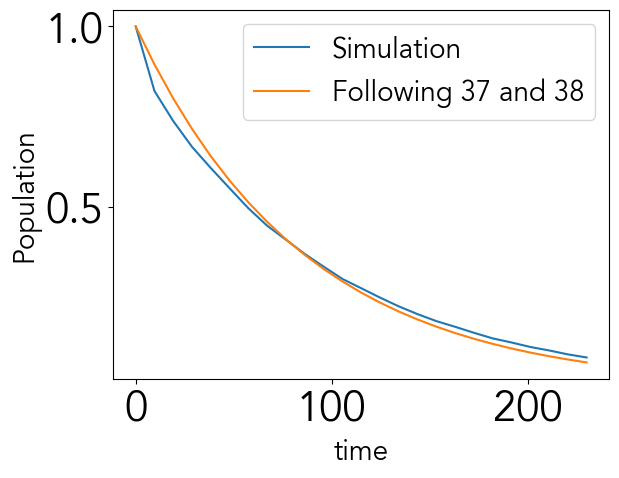

In [92]:
# Decay rate semi-numerical
vf = 3/2

a1, a2 = lattice.a1, lattice.a2
na, nb = compute_positions_along_direction_a1(lattice)
beta = delta * lambda_0 / vf

psi_x = (1/np.cosh(na[0]/lambda_0)) ** (beta)
x = join_arrays_interchange(nb[0], na[0])

A = 1/np.sqrt(np.sum((1/np.cosh(na[0]/lambda_0)) ** (2*beta)))



r0 = atom_pos[0] * a1 + atom_pos[1] * a2
x0 = r0[0]

psi_x0 = ((1/np.cosh(x0/lambda_0)) ** beta) * A

decay_semi_num = (G ** 2) * np.sqrt(3) * np.abs(psi_x0) **2 / vf


plt.plot(t, pe, label="Simulation")
# plt.plot(t, np.exp(-t * decay_rate), label='decay like eq 42')
plt.plot(t, np.exp(-t * decay_semi_num), label='Following 37 and 38')

# plt.plot(t, np.exp(-t * decay_rate_francesco), label='Decay rate 2')
plt.xlabel("time")
plt.ylabel("Population")

plt.legend(fontsize=20)

In [112]:
NMAX = 551
delta = 0.5
lambda_0 = 4
x0 = 0.
# OMEGA_0 = 0.014
OMEGA_0 = 0.
G = 0.1
atom_pos = (4,2)
NUM_POINTS = 25
TF = 230

t = np.linspace(0, TF, NUM_POINTS)
lattice = Graphene(nmax=NMAX, x0=x0, delta_0=delta, lambda_0=lambda_0, pbc="y", domain_wall_angle=0)

na, nb = lattice.n_real_pos

H = lattice.hamiltonian
new_dimension = lattice.num_sites() + 1
H.resize((new_dimension, new_dimension))
H = H.astype(np.cdouble)

H[-1, -1] = OMEGA_0
idx = lattice.coord_map["A"][atom_pos]

H[-1, idx] = G
H[idx, -1] = G

psi = np.zeros(new_dimension, dtype=np.cdouble)
psi[-1] = 1.

psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)

psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:lattice.la]
psi_b = psi_latt[:,lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2

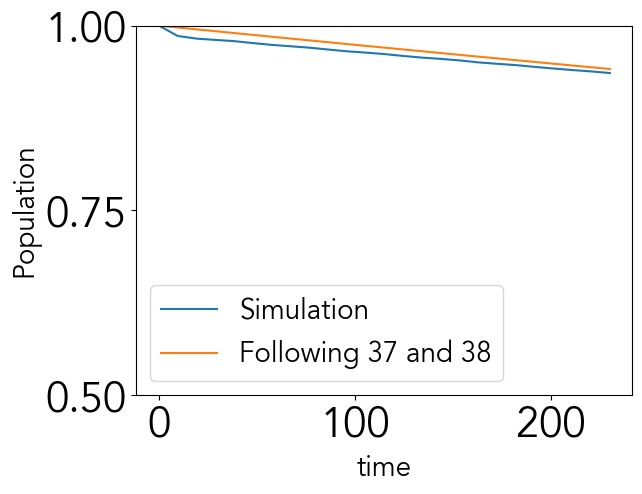

In [113]:
# Decay rate semi-numerical
vf = 3/2

a1, a2 = lattice.a1, lattice.a2
na, nb = compute_positions_along_direction_a1(lattice)
beta = delta * lambda_0 / vf

psi_x = (1/np.cosh(na[0]/lambda_0)) ** (beta)
x = join_arrays_interchange(nb[0], na[0])

A = 1/np.sqrt(np.sum((1/np.cosh(na[0]/lambda_0)) ** (2*beta)))



r0 = atom_pos[0] * a1 + atom_pos[1] * a2
x0 = r0[0]

psi_x0 = ((1/np.cosh(x0/lambda_0)) ** beta) * A

decay_semi_num = (G ** 2) * np.sqrt(3) * np.abs(psi_x0) **2 / vf


plt.plot(t, pe, label="Simulation")
# plt.plot(t, np.exp(-t * decay_rate), label='decay like eq 42')
plt.plot(t, np.exp(-t * decay_semi_num), label='Following 37 and 38')

# plt.plot(t, np.exp(-t * decay_rate_francesco), label='Decay rate 2')
plt.xlabel("time")
plt.ylabel("Population")

plt.ylim(0.5, 1)
plt.yticks([0.5, 0.75, 1.])

plt.legend(fontsize=20)

# Giant atoms

In [141]:
NMAX = 551
DELTA = 0.5
J = 1.
lambda_0 = 2
x0 = 0.
OMEGA_0 = 0.0
G = 0.3 / np.sqrt(2)
NUM_POINTS = 25
TF = 200

VALLEY = 1

leg1 = (0,0)
leg2 = (0,1)

print(f"Giant atom placed at \nr1 = {leg1}\nr2 = {leg2}")

PHI = compute_phase(leg1, leg2, VALLEY)

print(f"phi = {PHI}")
# PHI = np.pi/3


sys=System(
            lattice=Graphene(nmax=NMAX, J=J, x0=x0, delta_0=DELTA, lambda_0=lambda_0, pbc="y"),
            omega_0=OMEGA_0,
            g=G,
            legs=[
              Leg(site="A", pos=leg1),
              Leg(site="A", pos=leg2, phase=PHI),
            ]
    )

nx = range(- (NMAX // 2), NMAX // 2 + 1)
ny = range(- (NMAX // 2), NMAX // 2 + 1)

Nx, Ny = np.meshgrid(nx, ny)

na, nb = sys.lattice.n_real_pos

H = add_atom_to_hamiltonian(sys)
dim = H.shape[0]

t = np.linspace(0, TF, NUM_POINTS)

psi = np.zeros(dim, dtype=np.cdouble)
psi[-1] = 1. # Atom starts on excited state
psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)


psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:sys.lattice.la]
psi_b = psi_latt[:,sys.lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2

Giant atom placed at 
r1 = (0, 0)
r2 = (0, 1)
phi = 5.235987755982988


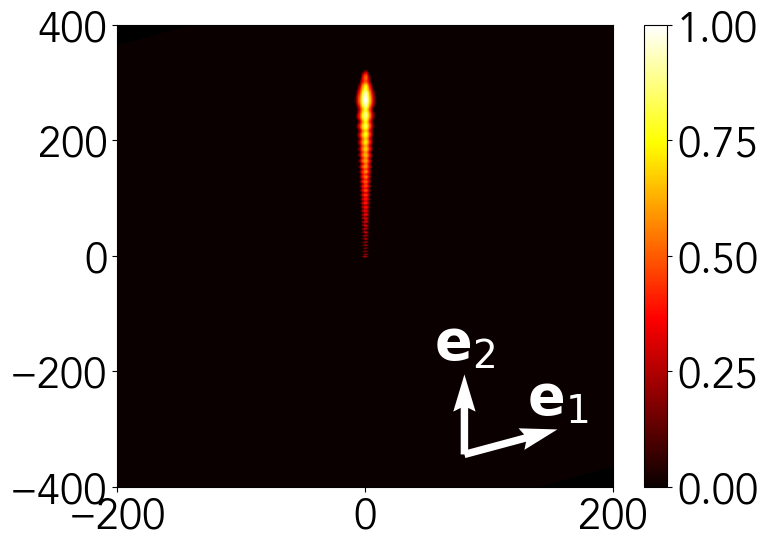

In [142]:
FIG_SIZE = (8, 6)
FILL = True
LOG_SCALE = True
VMAX = None
VMIN = -4.5


fig, ax = plt.subplots(figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], ax, s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE, rescale_to_0_1=True)

fig.colorbar(im, ax=ax, ticks=[0., 0.25, 0.5, 0.75, 1.])

if FILL:
    ax.set_facecolor("black")


ax.set_ylim(-400,400)
ax.set_xlim(-200, 200)

draw_basis_vectors(ax, [sys.lattice.a1, sys.lattice.a2], labels=(r"${\bf e}_1$", r"${\bf e}_2$"), pos=(0.7, 0.07), fontsize=40, scale=(50, 80), width=0.015)
plt.show()

fig.tight_layout()
# fig.savefig(PATH + "emission_giant_atom_phi=minus_piO3.pdf", bbox_inches="tight")

The decay rate is Gamma = 0.02259489588184814


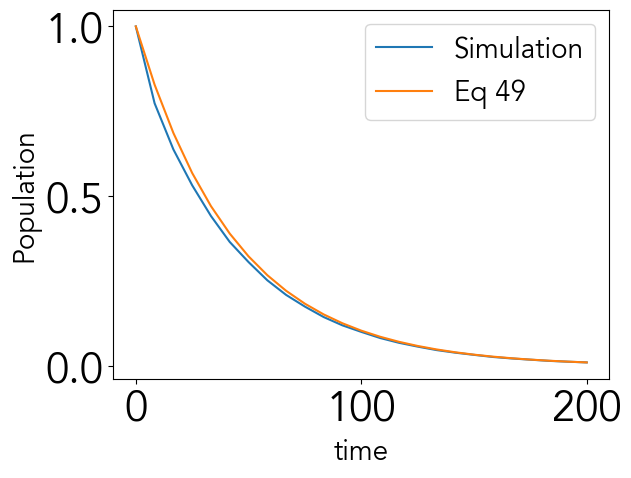

In [ ]:
K = np.array([2 * np.pi / 3, - 2 * np.pi/(3 * np.sqrt(3))])

vf = 3/2

a1, a2 = lattice.a1, lattice.a2
na, nb = compute_positions_along_direction_a1(lattice)
beta = DELTA * lambda_0 / vf

psi_x = (1/np.cosh(na[0]/lambda_0)) ** (beta)
x = join_arrays_interchange(nb[0], na[0])

A = 1/np.sqrt(np.sum((1/np.cosh(na[0]/lambda_0)) ** (2*beta)))

R = compute_position_legs(sys)
x0 = R[0][0]

psi_x0 = ((1/np.cosh(x0/lambda_0)) ** beta) * A
gl = np.array([G, G * np.exp(1j * PHI)])


# decay_semi_num = (G ** 2) * np.sqrt(3) * np.abs(psi_x0) **2 / vf
decay_semi_num =  (G ** 2) * np.abs(psi_x0) **2 /(np.sqrt(3)) # for each valley
gamma_giant = 0

for tau in [-1, 1]:
  arg = tau * K @ (R[1] - R[0]) - PHI
  modulus = 1 + np.exp(1j * arg)

  gamma_giant += np.abs(modulus) ** 2 * decay_semi_num

print(f"The decay rate is Gamma = {gamma_giant}")

plt.plot(t, pe, label="Simulation")
plt.plot(t, np.exp(-t * gamma_giant), label='Eq 49')

plt.xlabel("time")
plt.ylabel("Population")

plt.legend(fontsize=20)